In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pylab

In [2]:
params = {'legend.fontsize': 'xx-Large',
          'figure.figsize': (15, 6),
         'axes.labelsize': 30,
         'axes.titlesize':30,
         'xtick.labelsize':30,
         'ytick.labelsize':30,
    'font.family': 'STIXGeneral', 
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'text.usetex': True, # Enable LaTeX rendering
}

plt.rcParams.update(params)
pylab.rcParams.update(params)

/tmp/ipykernel_2073130/3048315964.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_cases     = cm.get_cmap("tab10", len(cases))


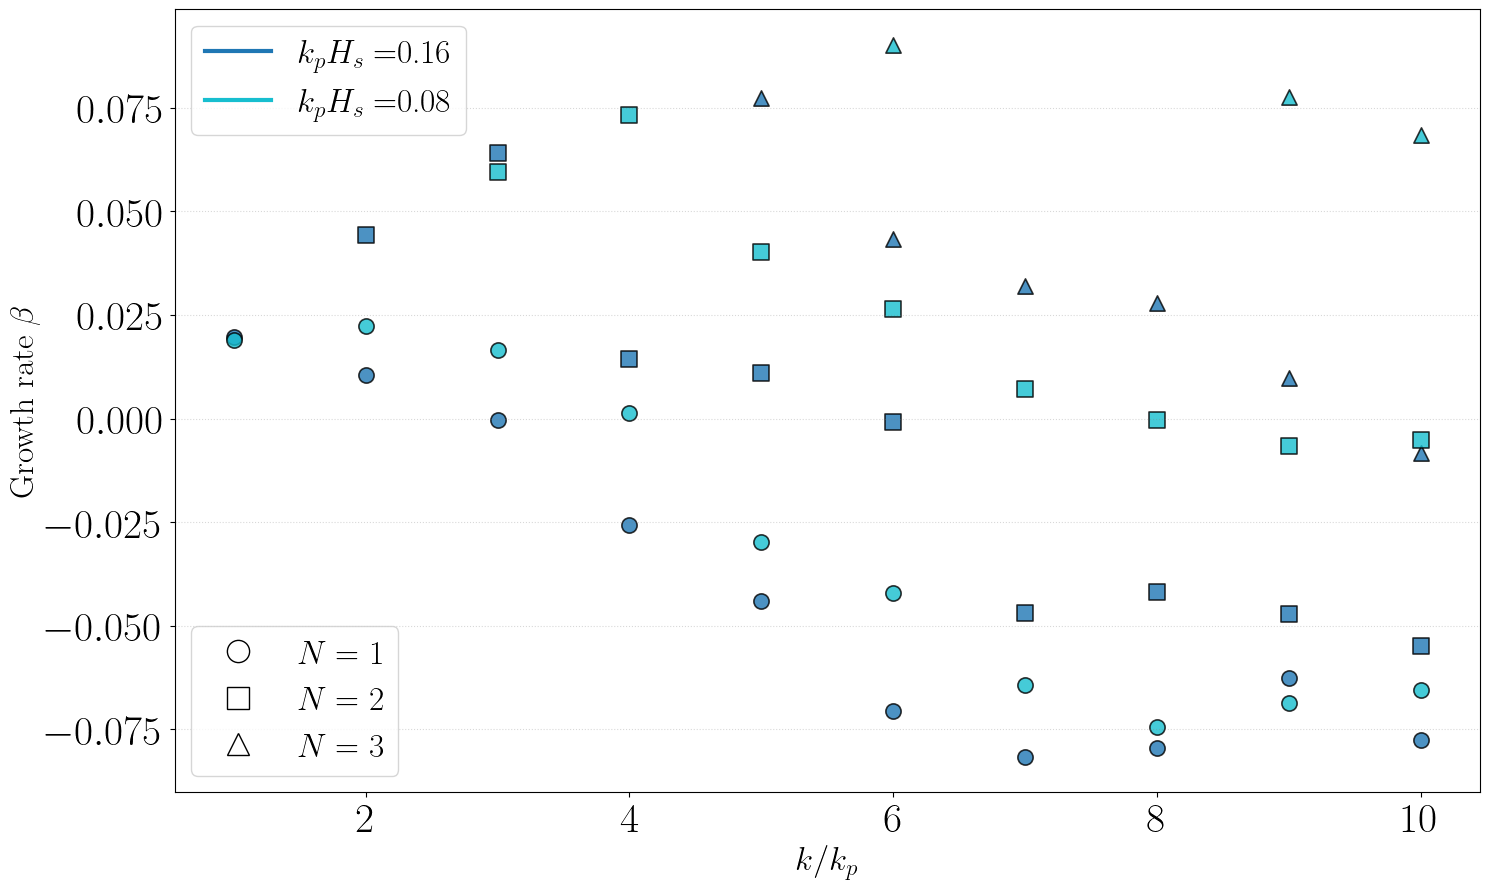

In [11]:
# Parámetros fijos
beta_path = '/projects/DEIKE/cmartinb/notebooks/betas/'
reW       = '2.5e4'
reA       = 720
maxLevel  = 10
Bo        = 200

# Lista de casos que quieras recorrer
cases = [
    (0.16, 0.50),
    (0.08, 0.50),
]

cmap_cases     = cm.get_cmap("tab10", len(cases))
branch_markers = ['o','s','^']

fig, ax = plt.subplots(figsize=(15,9))

for idx, (kpHs, uoc) in enumerate(cases):
    # Formatea siempre con dos decimales y luego reemplaza '.' → 'p'
    Pstr   = f"P{kpHs:.2f}".replace('.', 'p')    # "P0p16" o "P0p08"
    uocstr = f"uoc{uoc:.2f}".replace('.', 'p')    # "uoc0p50"
    fname  = (
        f"growthrates_3D_re{reA}_bo{Bo}_"
        f"{Pstr}_{uocstr}_reW{reW}_L{maxLevel}.csv"
    )
    path   = os.path.join(beta_path, fname)
    if not os.path.isfile(path):
        print("Warning: no se encontró", path)
        continue

    dfb       = pd.read_csv(path)
    unique_k  = sorted(dfb['k_kp'].unique())

    for ki in unique_k:
        subk       = dfb[dfb['k_kp']==ki]
        ops        = sorted(subk['omega_op'].unique())
        marker_map = {pos: branch_markers[i] for i,pos in enumerate(ops)}

        for _, row in subk.iterrows():
            ax.scatter(
                row['k_kp'], row['beta'],
                color=cmap_cases(idx),
                marker=marker_map[row['omega_op']],
                s=120, edgecolors='k', linewidths=1.2, alpha=0.8
            )

# Conecta cada rama ω/ωₚ fijo a lo largo de k/kp
if 'dfb' in locals():
    all_ops = sorted(dfb['omega_op'].unique())
    for pos in all_ops:
        df_pos = dfb[dfb['omega_op']==pos]
        if len(df_pos)>1:
            xs    = df_pos['k_kp'].values
            ys    = df_pos['beta'].values
            order = np.argsort(xs)
            ax.plot(xs[order], ys[order],
                    '--', color='gray', alpha=0.5, zorder=0)

# Estética
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.3)
ax.set_xlabel(r"$k/k_p$", fontsize=24)
ax.set_ylabel(r"Growth rate $\beta$", fontsize=24)
# Leyenda casos (colores)
legend_handles = [
    Line2D([0],[0], color=cmap_cases(i), lw=3)
    for i in range(len(cases))
]
legend_labels = [rf"$k_pH_s=${kpHs:.2f}" for kpHs,uoc in cases ]#,\ u_*/c={uoc:.2f}$

leg1 = ax.legend(legend_handles, legend_labels, loc='upper left', fontsize=24)
ax.add_artist(leg1)

# Leyenda ramas N (marcadores huecos)
handlesN = [
    Line2D([0],[0], marker=branch_markers[i], color='k',
           markerfacecolor='none', markersize=16, linestyle='None')
    for i in range(len(branch_markers))
]
labelsN = [f"$N={n}$" for n in (1,2,3)]
ax.legend(handlesN, labelsN,
          loc='lower left', fontsize=24)

plt.tight_layout()
plt.show()


KeyError: (0.08, 0.25)

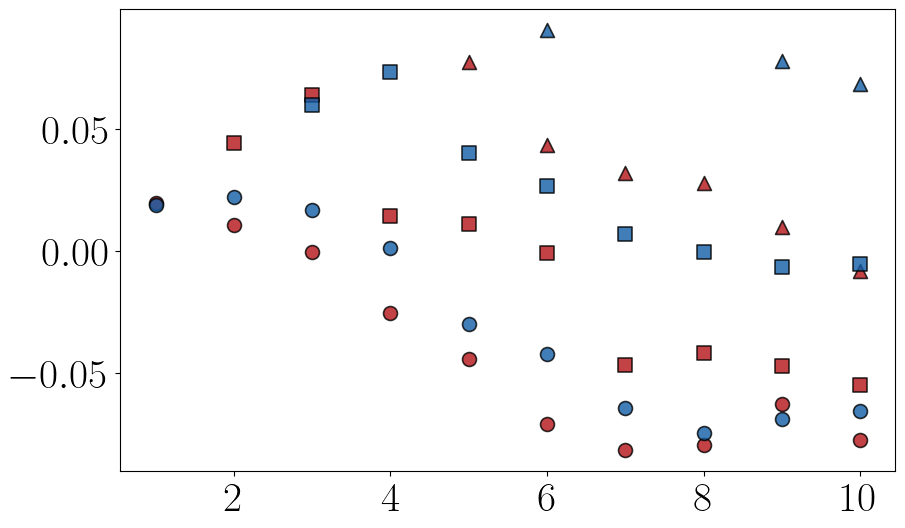

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# Parámetros fijos
beta_path = '/projects/DEIKE/cmartinb/notebooks/betas/'
reW       = '2.5e4'
reA       = 720
maxLevel  = 10
Bo        = 200

# Lista de casos
cases = [
    (0.16, 0.50),
    (0.08, 0.50),
    (0.08,0.25),
    # more cases
]

# Tus colormaps personalizados
cmap_08_50 = LinearSegmentedColormap.from_list(
    "blues_darker",
    cm.Blues(np.linspace(0.4, 1, 100))
)
cmap_16_50 = LinearSegmentedColormap.from_list(
    "reds_darker",
    cm.Reds(np.linspace(0.4, 1, 100))
)
# Mapear cada caso a su colormap
case_cmaps = {
    (0.16, 0.50): cmap_16_50,
    (0.08, 0.50): cmap_08_50,
    # agrega aquí futuros casos y sus cmaps
}

# Marcadores para ramas N
branch_markers = ['o','s','^']

fig, ax = plt.subplots(figsize=(10,6))

for kpHs, uoc in cases:
    # Formatea nombre de fichero
    Pstr   = f"P{kpHs:.2f}".replace('.', 'p')
    uocstr = f"uoc{uoc:.2f}".replace('.', 'p')
    fname  = (
        f"growthrates_3D_re{reA}_bo{Bo}_"
        f"{Pstr}_{uocstr}_reW{reW}_L{maxLevel}.csv"
    )
    path = os.path.join(beta_path, fname)
    if not os.path.isfile(path):
        print("Warning: no se encontró", path)
        continue

    dfb = pd.read_csv(path)
    cmap = case_cmaps[(kpHs, uoc)]

    for ki in sorted(dfb['k_kp'].unique()):
        subk = dfb[dfb['k_kp']==ki]
        ops  = sorted(subk['omega_op'].unique())
        marker_map = {pos: branch_markers[i] for i, pos in enumerate(ops)}

        for _, row in subk.iterrows():
            ax.scatter(
                row['k_kp'], row['beta'],
                color=cmap(0.7),           # usa un valor fijo de la paleta
                marker=marker_map[row['omega_op']],
                s=100, edgecolors='k', linewidths=1.2, alpha=0.8
            )

# Conecta cada rama ω/ωₚ fijo a lo largo de k/kp
if 'dfb' in locals():
    all_ops = sorted(dfb['omega_op'].unique())
    for pos in all_ops:
        df_pos = dfb[dfb['omega_op']==pos]
        if len(df_pos)>1:
            xs = df_pos['k_kp'].values
            ys = df_pos['beta'].values
            order = np.argsort(xs)
            ax.plot(xs[order], ys[order],
                    '--', color='gray', alpha=0.5, zorder=0)

# Estética
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.3)
ax.set_xlabel(r"$k/k_p$", fontsize=14)
ax.set_ylabel(r"Growth rate $\beta\,[T_p^{-1}]$", fontsize=14)
ax.set_title(r"Comparación de $\beta$ vs. $k/k_p$ con cmaps personalizados", fontsize=16)

# Leyenda casos (colores)
legend_handles = []
legend_labels  = []
for (kpHs, uoc), cmap in case_cmaps.items():
    # extrae un color representativo del centro del colormap
    color = cmap(0.6)
    legend_handles.append(Line2D([0],[0], color=color, lw=3))
    legend_labels.append(rf"$P={kpHs:.2f},\ u/c={uoc:.2f}$")

ax.legend(legend_handles, legend_labels,
          title="(P, u/c)", loc='upper left', fontsize=10)

# Leyenda ramas N (marcadores huecos)
handlesN = [
    Line2D([0],[0], marker=branch_markers[i], color='k',
           markerfacecolor='none', markersize=10, linestyle='None')
    for i in range(len(branch_markers))
]
labelsN = [f"$N={n}$" for n in (1,2,3)]
ax.legend(handlesN, labelsN, title="Branch N",
          loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()
